# Coalson M5.4: multi-window EQViT magnitude validation for EEW

## Purpose

This notebook upgrades the original `06_Coalson_m54_eqvit_real_event_validation.ipynb` experiment from a **single old 30-s EQViT magnitude model** to the **10 independently trained robust causal models** produced by `02_TXED_train_robust_EQViT_magnitude_multiwindow_EEW`.

The ten scientific horizons are:

**P+2, 3, 4, 5, 6, 7, 8, 9, 10, and 15 s**, always beginning at **P−1 s**.

The central question is no longer simply *“what magnitude does EQViT predict?”* Instead, we ask:

> **How rapidly does reliable magnitude information accumulate after the P arrival, which horizon is the best accuracy–latency compromise for the real M5.4 Coalson earthquake, and how stable are those conclusions across stations and realistic perturbations?**

### What this notebook tests

1. **Single-station accuracy** for every horizon.
2. **Network-fused accuracy** (median, mean, trimmed mean).
3. **True causal availability** using each station's observed P arrival plus its model horizon.
4. **Accuracy versus latency** for the real event.
5. **Station-to-station reliability and disagreement**.
6. **Distance, SNR, and amplitude dependence**.
7. **Paired station-by-station improvement** as more post-P data become available.
8. **Uncertainty** using station bootstrap confidence intervals.
9. **Robustness** to pick timing error, added noise, gain error, component loss, clipping, and data gaps.
10. **Optional comparison with the old P−1/P+29 s model**, if its checkpoint is available.
11. A quantitative **model-selection scorecard** to identify early, balanced, and accuracy-first operating points.

### Critical fairness rule

All ten models receive the same `(3000, 3)` tensor shape required by `EQViTMagnitude`. For a P+T model, **all samples after P+T are exactly zero**. Therefore the P+2 model cannot use P+3...P+29 information, even though the architectural tensor is 30 s long.

This notebook deliberately preserves the waveform preparation logic of notebook 06 and the causal masking/checkpoint convention of notebook 02.

In [1]:
from pathlib import Path
import json, math, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

try:
    from obspy import read_events, read
    from obspy.clients.fdsn import Client
except ImportError as e:
    raise ImportError("Install ObsPy first: pip install obspy") from e

from eqvit_torch.models import EQViTMagnitude

SEED = 2026
rng = np.random.default_rng(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = (
    "cuda" if torch.cuda.is_available()
    else ("mps" if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available()
          else "cpu")
)
print("PyTorch:", torch.__version__, "| device:", DEVICE)

PyTorch: 2.10.0+cu128 | device: cuda


## 1. Paths, model horizons, and reproducibility

The new training notebook saves checkpoints as

`models/eqvit_magnitude_Pm1_PpXXs_best.pt`

under `./outputs/txed_eqvit_magnitude_multiwindow_eew/`.

Only the path block below should normally require editing. The notebook performs explicit checkpoint/configuration audits before inference.

In [2]:
# --------------------------- EDIT PATHS HERE ---------------------------
QML_CANDIDATES = [
    Path("texnet2022wmmd.qml"),
    Path("/mnt/data/texnet2022wmmd.qml"),
]
QML_PATH = next((p for p in QML_CANDIDATES if p.exists()), QML_CANDIDATES[0])

TRAIN_OUTPUT_DIR = Path("./outputs/txed_eqvit_magnitude_multiwindow_eew")
MODEL_DIR = TRAIN_OUTPUT_DIR / "models"

# Optional old 30-s baseline from notebook 06.
OLD_CHECKPOINT_CANDIDATES = [
    Path("./outputs/txed_eqvit_magnitude_v0/txed_eqvit_magnitude_best.pt"),
    Path("./outputs/txed_eqvit_magnitude/txed_eqvit_magnitude_best.pt"),
]
OLD_BEST = next((p for p in OLD_CHECKPOINT_CANDIDATES if p.exists()), None)

OUTPUT_DIR = Path("./outputs/coalson_m54_eqvit_multiwindow_comparison")
WAVEFORM_DIR = OUTPUT_DIR / "waveforms"
FIG_DIR = OUTPUT_DIR / "figures"
for d in [OUTPUT_DIR, WAVEFORM_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

POST_P_WINDOWS_S = [2,3,4,5,6,7,8,9,10,15]
FS = 100.0
PRE_P_S = 1.0
MODEL_N = 3000
MODEL_POST_P_S = MODEL_N / FS - PRE_P_S  # +29 s
PRE_N = int(round(PRE_P_S * FS))

DOWNLOAD_PRE_S = 3.0
DOWNLOAD_POST_S = 31.0
ONLY_WEIGHTED_P = False
TRIM_FRACTION = 0.10
N_BOOT = 5000

assert len(POST_P_WINDOWS_S) == 10
assert MODEL_N == 3000
print("QuakeML:", QML_PATH)
print("New model directory:", MODEL_DIR)
print("Old 30-s baseline:", OLD_BEST)
print("Horizons:", POST_P_WINDOWS_S)

QuakeML: texnet2022wmmd.qml
New model directory: outputs/txed_eqvit_magnitude_multiwindow_eew/models
Old 30-s baseline: outputs/txed_eqvit_magnitude_v0/txed_eqvit_magnitude_best.pt
Horizons: [2, 3, 4, 5, 6, 7, 8, 9, 10, 15]


## 2. Preflight audit: do not silently compare the wrong models

A scientifically meaningful comparison requires all ten independently trained checkpoints. This cell reports missing files immediately. It also records checkpoint metadata so that the final tables can show validation MAE, epoch, and saved causal configuration alongside Coalson performance.

In [3]:
def checkpoint_path(T):
    return MODEL_DIR / f"eqvit_magnitude_Pm1_Pp{T:02d}s_best.pt"

audit = []
for T in POST_P_WINDOWS_S:
    p = checkpoint_path(T)
    row = {"post_p_s": T, "checkpoint": str(p), "exists": p.exists()}
    if p.exists():
        ck = torch.load(p, map_location="cpu")
        cfg = ck.get("config", {}) if isinstance(ck, dict) else {}
        row.update(
            epoch=ck.get("epoch", np.nan) if isinstance(ck, dict) else np.nan,
            txed_val_mae=ck.get("val_mae", np.nan) if isinstance(ck, dict) else np.nan,
            causal_mask=cfg.get("causal_mask", None),
            tensor_samples=cfg.get("tensor_samples", cfg.get("window_samples", None)),
            saved_post_p_s=cfg.get("post_p_s", None),
            robust_augment=cfg.get("robust_augment", None),
        )
    audit.append(row)

checkpoint_audit = pd.DataFrame(audit)
display(checkpoint_audit)

missing = checkpoint_audit.loc[~checkpoint_audit.exists, "checkpoint"].tolist()
if missing:
    print("\nMISSING CHECKPOINTS:")
    print("\n".join(missing))
    print("\nTrain/copy the 10 models from notebook 02, or edit MODEL_DIR.")
else:
    print("All 10 multi-window checkpoints are present.")

,post_p_s,checkpoint,exists,epoch,txed_val_mae,causal_mask,tensor_samples,saved_post_p_s,robust_augment
0,2,outputs/txed_eqvit_magnitude_multiwindow_eew/m...,True,88,0.295232,True,3000,2,True
1,3,outputs/txed_eqvit_magnitude_multiwindow_eew/m...,True,60,0.256254,True,3000,3,True
2,4,outputs/txed_eqvit_magnitude_multiwindow_eew/m...,True,48,0.258802,True,3000,4,True
3,5,outputs/txed_eqvit_magnitude_multiwindow_eew/m...,True,18,0.245535,True,3000,5,True
4,6,outputs/txed_eqvit_magnitude_multiwindow_eew/m...,True,32,0.221005,True,3000,6,True
5,7,outputs/txed_eqvit_magnitude_multiwindow_eew/m...,True,32,0.233331,True,3000,7,True
6,8,outputs/txed_eqvit_magnitude_multiwindow_eew/m...,True,46,0.202807,True,3000,8,True
7,9,outputs/txed_eqvit_magnitude_multiwindow_eew/m...,True,46,0.194475,True,3000,9,True
8,10,outputs/txed_eqvit_magnitude_multiwindow_eew/m...,True,37,0.212130,True,3000,10,True
9,15,outputs/txed_eqvit_magnitude_multiwindow_eew/m...,True,62,0.168976,True,3000,15,True


All 10 multi-window checkpoints are present.


## 3. Read the Coalson event and construct the P-pick table

As in notebook 06, the event truth is taken from the QuakeML preferred magnitude and preferred origin. The model comparison therefore uses one locked reference magnitude for all horizons.

In [4]:
assert QML_PATH.exists(), (
    f"Missing {QML_PATH}. Place the Coalson QuakeML (texnet2022wmmd.qml) here "
    "or edit QML_PATH."
)

cat = read_events(str(QML_PATH))
event = cat[0]
origin = event.preferred_origin() or event.origins[0]
magnitude = event.preferred_magnitude() or event.magnitudes[0]

TRUE_M = float(magnitude.mag)
ORIGIN_TIME = origin.time
EV_LAT = float(origin.latitude)
EV_LON = float(origin.longitude)
EV_DEPTH_KM = float(origin.depth or 0) / 1000.0

print(f"Origin: {ORIGIN_TIME}")
print(f"Location: {EV_LAT:.5f}, {EV_LON:.5f}, depth={EV_DEPTH_KM:.2f} km")
print(f"Reference magnitude: {magnitude.magnitude_type}={TRUE_M:.4f}")

arr_by_pick = {str(a.pick_id): a for a in origin.arrivals if a.pick_id}
rows = []
for p in event.picks:
    if (p.phase_hint or "").upper() != "P":
        continue
    w = p.waveform_id
    a = arr_by_pick.get(str(p.resource_id))
    rows.append(dict(
        pick_id=str(p.resource_id),
        network=w.network_code or "*",
        station=w.station_code,
        location=w.location_code if w.location_code is not None else "*",
        pick_channel=w.channel_code or "",
        p_time=p.time,
        distance_deg=float(a.distance) if a is not None and a.distance is not None else np.nan,
        azimuth_deg=float(a.azimuth) if a is not None and a.azimuth is not None else np.nan,
        time_residual_s=float(a.time_residual) if a is not None and a.time_residual is not None else np.nan,
        time_weight=float(a.time_weight) if a is not None and a.time_weight is not None else np.nan,
    ))

picks = pd.DataFrame(rows).sort_values("p_time").reset_index(drop=True)
picks["distance_km_approx"] = picks.distance_deg * 111.195
picks["p_elapsed_s"] = picks.p_time.map(lambda t: float(t - ORIGIN_TIME))
if ONLY_WEIGHTED_P:
    picks = picks[picks.time_weight.fillna(0) > 0].reset_index(drop=True)

print("P picks:", len(picks), "| unique stations:",
      picks[["network","station"]].drop_duplicates().shape[0])
display(picks)

Origin: 2022-11-16T21:32:44.481830Z
Location: 31.63675, -103.99879, depth=6.90 km
Reference magnitude: ML(TexNet)=5.4330
P picks: 71 | unique stations: 69


,pick_id,network,station,location,pick_channel,p_time,distance_deg,azimuth_deg,time_residual_s,time_weight,distance_km_approx,p_elapsed_s
0,smi:org.gfz-potsdam.de/geofon/Pick/20221117015...,TX,PB24,00,HHZ,2022-11-16T21:32:46.157945Z,0.023452,223.866095,-0.036488,1.245844,2.607692,1.676115
1,smi:org.gfz-potsdam.de/geofon/Pick/20221117015...,4O,WB03,00,HHN,2022-11-16T21:32:46.256619Z,0.036511,135.827024,-0.048001,1.230867,4.059882,1.774789
2,smi:org.gfz-potsdam.de/geofon/Pick/20221117164...,TX,PB40,00,HNZ,2022-11-16T21:32:46.536693Z,0.055535,84.773108,0.028165,1.262350,6.175177,2.054863
3,smi:org.gfz-potsdam.de/geofon/Pick/20221117015...,TX,PB20,00,HHN,2022-11-16T21:32:46.573785Z,0.054426,261.089902,0.056830,1.232800,6.051941,2.091955
4,smi:org.gfz-potsdam.de/geofon/Pick/20221116214...,TX,PB34,00,HHZ,2022-11-16T21:32:46.649570Z,0.052030,320.522530,0.176753,0.923594,5.785455,2.167740
...,...,...,...,...,...,...,...,...,...,...,...,...
66,smi:org.gfz-potsdam.de/geofon/Pick/20221116215...,TX,PB30,00,HHZ,2022-11-16T21:32:57.975571Z,0.679060,121.763988,-0.035423,1.091569,75.508093,13.493741
67,smi:org.gfz-potsdam.de/geofon/Pick/20221117165...,TX,PB22,00,HHZ,2022-11-16T21:33:01.373076Z,0.948646,116.637436,-1.585059,0.000000,105.484637,16.891246
68,smi:org.gfz-potsdam.de/geofon/Pick/20221117165...,TX,PB05,00,HHZ,2022-11-16T21:33:01.729035Z,0.921276,141.269094,-0.761902,0.000000,102.441265,17.247205
69,smi:org.gfz-potsdam.de/geofon/Pick/20221117165...,4O,DB03,*,HHZ,2022-11-16T21:33:02.281820Z,0.944432,123.499810,-0.606194,0.000000,105.016099,17.799990


## 4. Download/cache the same three-component TexNet waveforms

Waveforms are downloaded once and reused for all ten models. This is essential: **the horizon/model is the experimental variable; the station set and raw waveform are held fixed**.

In [5]:
client = Client("texnet")
print(client)

def download_station(row):
    net, sta = row.network, row.station
    loc = row.location if row.location not in (None, "") else "*"
    cache = WAVEFORM_DIR / f"{net}.{sta}.{str(loc).replace('*','ALL')}.mseed"
    if cache.exists() and cache.stat().st_size > 0:
        return read(str(cache)), "cache"
    st = client.get_waveforms(
        net, sta, loc, "*",
        row.p_time - DOWNLOAD_PRE_S,
        row.p_time + DOWNLOAD_POST_S,
        attach_response=False,
    )
    if len(st):
        st.write(str(cache), format="MSEED")
    return st, "download"

streams, logs = {}, []
for r in picks.itertuples():
    key = (r.network, r.station)
    if key in streams:
        continue
    try:
        st, src = download_station(r)
        streams[key] = st
        logs.append(dict(network=r.network, station=r.station, ok=True,
                         n_traces=len(st), source=src, error=""))
        print(f"OK   {r.network}.{r.station}: {len(st)} traces ({src})")
    except Exception as e:
        logs.append(dict(network=r.network, station=r.station, ok=False,
                         n_traces=0, source="", error=repr(e)))
        print(f"FAIL {r.network}.{r.station}: {e}")

download_log = pd.DataFrame(logs)
download_log.to_csv(OUTPUT_DIR / "download_log.csv", index=False)
display(download_log)

FDSN Webservice Client (base url: http://rtserve.beg.utexas.edu)
Available Services: 'dataselect' (v1.1.3), 'station' (v1.1.5)

Use e.g. client.help('dataselect') for the
parameter description of the individual services
or client.help() for parameter description of
all webservices.
OK   TX.PB24: 3 traces (download)
OK   4O.WB03: 3 traces (download)
OK   TX.PB40: 6 traces (download)
OK   TX.PB20: 3 traces (download)
OK   TX.PB34: 6 traces (download)
OK   TX.PB23: 3 traces (download)
OK   TX.PB25: 3 traces (download)
OK   TX.PB31: 3 traces (download)
OK   4O.WB01: 4 traces (download)
OK   TX.PB33: 6 traces (download)
OK   4O.WB04: 6 traces (download)
OK   4O.WB02: 3 traces (download)
OK   TX.PB43: 6 traces (download)
FAIL TX.PB13: No data available for request.
HTTP Status code: 204
Detailed response of server:


OK   4O.SA06: 3 traces (download)
OK   4O.WB05: 6 traces (download)
OK   4O.CV01: 3 traces (download)
OK   4O.SA02: 3 traces (download)
OK   4O.SA04: 6 traces (download)
OK   TX

,network,station,ok,n_traces,source,error
0,TX,PB24,True,3,download,
1,4O,WB03,True,3,download,
2,TX,PB40,True,6,download,
3,TX,PB20,True,3,download,
4,TX,PB34,True,6,download,
...,...,...,...,...,...,...
64,TX,PB30,True,3,download,
65,TX,PB22,True,3,download,
66,TX,PB05,True,6,download,
67,4O,DB03,True,3,download,


## 5. Reproduce the training tensor and impose strict causal masks

The preprocessing below intentionally follows notebook 06 for channel-family selection, interpolation, and P-centered alignment.

For every station we first build the full **P−1 to P+29 s** `(3000,3)` tensor. Then, for horizon `T`, only the first `1+T` seconds remain visible and all later samples are hard-zeroed.

The DC baseline is estimated from the **one second before P**, exactly matching the new robust training notebook.

In [6]:
PREFIX_PRIORITY = ["HH","BH","EH","CH","HN","SH"]

def choose_three_components(st):
    candidates = [
        tr for tr in st
        if len(tr.stats.channel or "") >= 3 and tr.stats.channel[-1] in "ZNE12"
    ]
    groups = {}
    for tr in candidates:
        groups.setdefault((tr.stats.location or "", tr.stats.channel[:2]), []).append(tr)

    def score(item):
        (loc, pref), trs = item
        suff = {tr.stats.channel[-1] for tr in trs}
        complete = ("Z" in suff) and ({"N","E"} <= suff or {"1","2"} <= suff)
        pri = PREFIX_PRIORITY.index(pref) if pref in PREFIX_PRIORITY else 99
        return (0 if complete else 1, pri,
                -max(float(tr.stats.sampling_rate) for tr in trs))

    for _, trs in sorted(groups.items(), key=score):
        by = {tr.stats.channel[-1]: tr for tr in trs}
        if "Z" in by and "N" in by and "E" in by:
            return [by["Z"].copy(), by["N"].copy(), by["E"].copy()]
        if "Z" in by and "1" in by and "2" in by:
            return [by["Z"].copy(), by["1"].copy(), by["2"].copy()]
    raise ValueError("No complete Z+2-horizontal channel family")

def station_to_full_window(st, ptime):
    trs = choose_three_components(st)
    out, chans, fs0 = [], [], []
    start = ptime - PRE_P_S
    for tr in trs:
        chans.append(tr.id)
        fs0.append(float(tr.stats.sampling_rate))
        tr.detrend("constant")
        tr.interpolate(
            sampling_rate=FS, starttime=start, npts=MODEL_N, method="linear"
        )
        x = np.asarray(tr.data, np.float32)
        if x.shape != (MODEL_N,) or not np.isfinite(x).all():
            raise ValueError(f"Bad {tr.id}: {x.shape}")
        out.append(x)
    w = np.stack(out, axis=1).astype(np.float32)
    return w, chans, fs0

def causalize(full_w, T):
    visible_n = int(round((PRE_P_S + T) * FS))
    w = np.asarray(full_w, np.float32).copy()
    baseline = w[:PRE_N].mean(axis=0, keepdims=True)
    w[:visible_n] -= baseline
    w[visible_n:] = 0.0
    assert w.shape == (MODEL_N, 3)
    assert np.count_nonzero(w[visible_n:]) == 0
    return w

full_windows, qc_rows, rejected = {}, [], []
for r in picks.itertuples():
    key = (r.network, r.station)
    if key not in streams:
        rejected.append({**r._asdict(), "reason": "download unavailable"})
        continue
    try:
        w, chans, fs0 = station_to_full_window(streams[key], r.p_time)
        pre = np.sqrt(np.mean((w[:PRE_N] - w[:PRE_N].mean(0, keepdims=True))**2, axis=0))
        post15 = w[PRE_N:int((PRE_P_S+15)*FS)]
        post15 = post15 - w[:PRE_N].mean(0, keepdims=True)
        sig = np.sqrt(np.mean(post15**2, axis=0))
        snr = 20*np.log10((np.linalg.norm(sig)+1e-20)/(np.linalg.norm(pre)+1e-20))
        peak = np.max(np.abs(post15), axis=0)
        full_windows[key] = w
        qc_rows.append(dict(
            network=r.network, station=r.station,
            channels=" | ".join(chans),
            original_fs=" | ".join(f"{x:g}" for x in fs0),
            snr_proxy_db=float(snr),
            peak_vector_counts=float(np.linalg.norm(peak)),
        ))
    except Exception as e:
        rejected.append({**r._asdict(), "reason": repr(e)})

qc = pd.DataFrame(qc_rows)
rej = pd.DataFrame(rejected)
print("Usable stations:", len(full_windows), "| rejected:", len(rej))
display(qc)
if len(rej):
    display(rej[["network","station","reason"]])

Usable stations: 48 | rejected: 21


,network,station,channels,original_fs,snr_proxy_db,peak_vector_counts
0,TX,PB24,TX.PB24.00.HHZ | TX.PB24.00.HHN | TX.PB24.00.HHE,100 | 100 | 100,89.678925,1.433101e+07
1,4O,WB03,4O.WB03.00.HHZ | 4O.WB03.00.HHN | 4O.WB03.00.HHE,200 | 200 | 200,80.122597,1.537840e+07
2,TX,PB40,TX.PB40.00.HHZ | TX.PB40.00.HH1 | TX.PB40.00.HH2,100 | 100 | 100,74.848335,1.460400e+07
3,TX,PB20,TX.PB20.00.HHZ | TX.PB20.00.HHN | TX.PB20.00.HHE,100 | 100 | 100,89.860168,1.089083e+07
4,TX,PB34,TX.PB34.00.HHZ | TX.PB34.00.HH1 | TX.PB34.00.HH2,100 | 100 | 100,59.419678,1.483363e+07
5,TX,PB23,TX.PB23.00.HHZ | TX.PB23.00.HHN | TX.PB23.00.HHE,100 | 100 | 100,91.824120,1.144454e+07
6,TX,PB25,TX.PB25.00.HHZ | TX.PB25.00.HHN | TX.PB25.00.HHE,100 | 100 | 100,70.916168,1.364446e+07
7,TX,PB31,TX.PB31.00.HHZ | TX.PB31.00.HH1 | TX.PB31.00.HH2,100 | 100 | 100,77.741119,1.361134e+07
8,4O,WB01,4O.WB01.00.HHZ | 4O.WB01.00.HHN | 4O.WB01.00.HHE,200 | 200 | 200,78.092621,1.267009e+07
9,TX,PB33,TX.PB33.00.HHZ | TX.PB33.00.HH1 | TX.PB33.00.HH2,200 | 200 | 200,95.110542,1.437551e+07


,network,station,reason
0,4O,WB04,ValueError('The new array must be fully contai...
1,TX,PB13,download unavailable
2,4O,WB05,ValueError('The new array must be fully contai...
3,4O,SA04,ValueError('The new array must be fully contai...
4,4O,WB12,ValueError('The new array must be fully contai...
5,4O,WB11,ValueError('The new array must be fully contai...
6,4O,WB09,ValueError('The new array must be fully contai...
7,GM,NMP11,download unavailable
8,4O,WB10,ValueError('The new array must be fully contai...
9,4O,WB06,ValueError('The new array must be fully contai...


## 6. Visual causality audit on a real Coalson station

This plot is an important sanity check. It demonstrates what each model actually receives. The later waveform is present in the downloaded record but **must be identically zero in the tensor presented to an early model**.

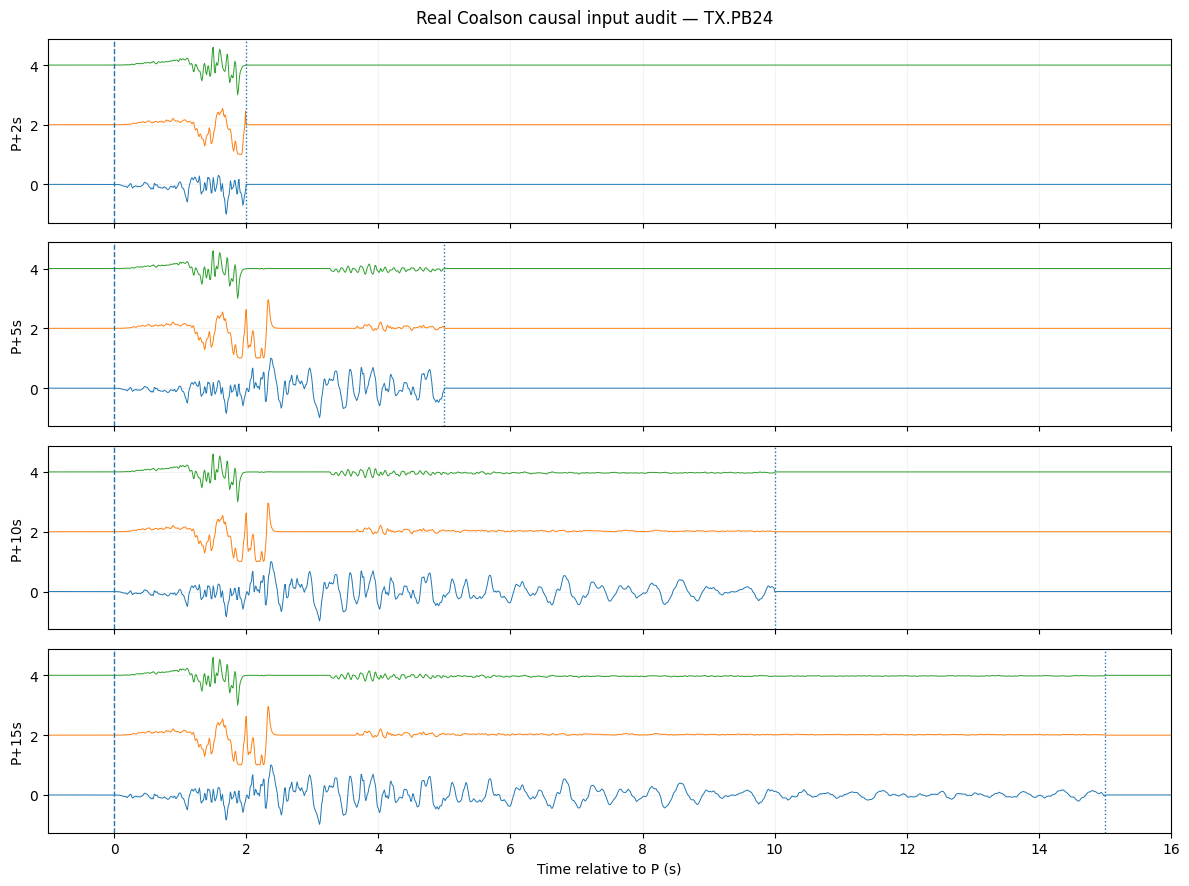

In [7]:
example_key = next(iter(full_windows))
fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
t = np.arange(MODEL_N)/FS - PRE_P_S

for ax, T in zip(axes, [2,5,10,15]):
    w = causalize(full_windows[example_key], T)
    scale = np.max(np.abs(w), axis=0)
    scale[scale == 0] = 1
    for c in range(3):
        ax.plot(t, w[:,c]/scale[c] + 2*c, lw=.7)
    ax.axvline(0, ls="--", lw=1, label="P")
    ax.axvline(T, ls=":", lw=1, label=f"P+{T}s")
    ax.set_ylabel(f"P+{T}s")
    ax.grid(alpha=.15)
axes[-1].set_xlim(-1, 16)
axes[-1].set_xlabel("Time relative to P (s)")
fig.suptitle(f"Real Coalson causal input audit — {example_key[0]}.{example_key[1]}")
plt.tight_layout()
plt.show()

## 7. Load all ten independently trained models

Do not reuse one model with ten masks: notebook 02 trains **ten separate parameter sets**. This distinction is central to the experiment.

In [8]:
def load_horizon_model(T):
    path = checkpoint_path(T)
    if not path.exists():
        raise FileNotFoundError(
            f"Missing {path}. Run notebook 02 to train P+{T}s, or edit MODEL_DIR."
        )
    ck = torch.load(path, map_location=DEVICE)
    state = ck["state_dict"] if isinstance(ck, dict) and "state_dict" in ck else ck
    cfg = ck.get("config", {}) if isinstance(ck, dict) else {}

    # Defensive checks against accidentally using the wrong checkpoint.
    if cfg.get("post_p_s", T) is not None:
        assert float(cfg.get("post_p_s", T)) == float(T), (T, cfg)
    if cfg.get("tensor_samples", MODEL_N) is not None:
        assert int(cfg.get("tensor_samples", MODEL_N)) == MODEL_N

    m = EQViTMagnitude().to(DEVICE)
    m.load_state_dict(state)
    m.eval()
    return m, ck

# Smoke-test every checkpoint with the same real station but its own causal horizon.
for T in POST_P_WINDOWS_S:
    m, ck = load_horizon_model(T)
    x = causalize(full_windows[example_key], T)
    with torch.no_grad():
        y = float(m(torch.from_numpy(np.ascontiguousarray(x))[None].to(DEVICE)).reshape(-1).cpu())
    print(f"P+{T:02d}s | epoch={ck.get('epoch',None)} | val_MAE={ck.get('val_mae',np.nan):.4f} | example M={y:.3f}")
    del m
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

P+02s | epoch=88 | val_MAE=0.2952 | example M=4.099
P+03s | epoch=60 | val_MAE=0.2563 | example M=4.656
P+04s | epoch=48 | val_MAE=0.2588 | example M=4.239
P+05s | epoch=18 | val_MAE=0.2455 | example M=5.149
P+06s | epoch=32 | val_MAE=0.2210 | example M=4.587
P+07s | epoch=32 | val_MAE=0.2333 | example M=4.394
P+08s | epoch=46 | val_MAE=0.2028 | example M=5.176
P+09s | epoch=46 | val_MAE=0.1945 | example M=3.897
P+10s | epoch=37 | val_MAE=0.2121 | example M=4.580
P+15s | epoch=62 | val_MAE=0.1690 | example M=4.475


## 8. Run the complete station × horizon experiment

Every usable station is evaluated by every horizon model. This produces a paired design: for a given station, changes with `T` are attributable to the different causal window/model rather than to a different station sample.

In [9]:
@torch.no_grad()
def infer_model(model, w):
    x = torch.from_numpy(np.ascontiguousarray(w))[None].to(DEVICE)
    return float(model(x).reshape(-1).cpu())

pick_lookup = picks.set_index(["network","station"], drop=False)
records = []

for T in POST_P_WINDOWS_S:
    print("Inference horizon P+", T, "s")
    model, ck = load_horizon_model(T)
    for key, full_w in full_windows.items():
        net, sta = key
        r = pick_lookup.loc[key]
        # If duplicate picks somehow exist, use first.
        if isinstance(r, pd.DataFrame):
            r = r.iloc[0]
        w = causalize(full_w, T)
        pm = infer_model(model, w)
        q = qc[(qc.network == net) & (qc.station == sta)].iloc[0]
        records.append(dict(
            post_p_s=T,
            network=net, station=sta,
            p_elapsed_s=float(r.p_elapsed_s),
            available_at_elapsed_s=float(r.p_elapsed_s + T),
            distance_km_approx=float(r.distance_km_approx),
            azimuth_deg=float(r.azimuth_deg),
            snr_proxy_db=float(q.snr_proxy_db),
            peak_vector_counts=float(q.peak_vector_counts),
            predicted_magnitude=pm,
            catalog_magnitude=TRUE_M,
            residual=pm-TRUE_M,
            abs_error=abs(pm-TRUE_M),
            checkpoint_epoch=ck.get("epoch", np.nan),
            txed_val_mae=ck.get("val_mae", np.nan),
        ))
    del model
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

pred_all = pd.DataFrame(records)
pred_all.to_csv(OUTPUT_DIR / "coalson_station_predictions_all_horizons.csv", index=False)
display(pred_all.head())
print("Rows:", len(pred_all), "=", pred_all.station.nunique(), "stations ×",
      pred_all.post_p_s.nunique(), "horizons")

Inference horizon P+ 2 s
Inference horizon P+ 3 s
Inference horizon P+ 4 s


/tmp/ipykernel_948607/1290879060.py:14: PerformanceWarning: indexing past lexsort depth may impact performance.
  r = pick_lookup.loc[key]


Inference horizon P+ 5 s
Inference horizon P+ 6 s
Inference horizon P+ 7 s
Inference horizon P+ 8 s
Inference horizon P+ 9 s
Inference horizon P+ 10 s
Inference horizon P+ 15 s


,post_p_s,network,station,p_elapsed_s,available_at_elapsed_s,distance_km_approx,azimuth_deg,snr_proxy_db,peak_vector_counts,predicted_magnitude,catalog_magnitude,residual,abs_error,checkpoint_epoch,txed_val_mae
0,2,TX,PB24,1.676115,3.676115,2.607692,223.866095,89.678925,14331013.0,4.099475,5.432978,-1.333503,1.333503,88,0.295232
1,2,4O,WB03,1.774789,3.774789,4.059882,135.827024,80.122597,15378401.0,4.288307,5.432978,-1.144671,1.144671,88,0.295232
2,2,TX,PB40,2.054863,4.054863,6.175177,84.773108,74.848335,14604002.0,4.088957,5.432978,-1.344021,1.344021,88,0.295232
3,2,TX,PB20,2.091955,4.091955,6.051941,261.089902,89.860168,10890832.0,4.350076,5.432978,-1.082902,1.082902,88,0.295232
4,2,TX,PB34,2.167740,4.167740,5.785455,320.522530,59.419678,14833628.0,4.128947,5.432978,-1.304031,1.304031,88,0.295232


Rows: 480 = 48 stations × 10 horizons


## 9. Headline model comparison: station accuracy + network fusion + uncertainty

For a real event, station predictions are not independent measurements of truth in a strict statistical sense, but their spread is operationally useful. We report:

- station MAE / RMSE / bias,
- network median, mean, and 10% trimmed mean,
- network-median error,
- interquartile spread,
- bootstrap 95% CI of the station median,
- fraction of stations within ±0.2 and ±0.5 magnitude units.

The median is emphasized because one problematic station should not dominate an EEW network estimate.

In [10]:
def trimmed_mean(x, frac=.10):
    x = np.sort(np.asarray(x, float))
    k = int(np.floor(frac*len(x)))
    return float(np.mean(x[k:len(x)-k])) if len(x)-2*k > 0 else float(np.mean(x))

summary_rows = []
boot_rows = []

for T, d in pred_all.groupby("post_p_s"):
    v = d.predicted_magnitude.to_numpy(float)
    e = v - TRUE_M
    boots = np.array([
        np.median(rng.choice(v, size=len(v), replace=True))
        for _ in range(N_BOOT)
    ])
    lo, hi = np.quantile(boots, [.025, .975])
    summary_rows.append(dict(
        post_p_s=int(T),
        n_stations=len(d),
        station_mae=float(np.mean(np.abs(e))),
        station_rmse=float(np.sqrt(np.mean(e*e))),
        station_bias=float(np.mean(e)),
        station_std=float(np.std(e)),
        network_median=float(np.median(v)),
        network_mean=float(np.mean(v)),
        network_trimmed_mean=trimmed_mean(v, TRIM_FRACTION),
        network_median_error=float(np.median(v)-TRUE_M),
        network_median_abs_error=float(abs(np.median(v)-TRUE_M)),
        station_iqr=float(np.quantile(v,.75)-np.quantile(v,.25)),
        ci95_lo=float(lo), ci95_hi=float(hi),
        ci95_width=float(hi-lo),
        frac_within_0p2=float(np.mean(np.abs(e) <= .2)),
        frac_within_0p5=float(np.mean(np.abs(e) <= .5)),
        txed_val_mae=float(d.txed_val_mae.iloc[0]),
    ))
    boot_rows.append(pd.DataFrame({"post_p_s":T, "bootstrap_network_median":boots}))

summary_df = pd.DataFrame(summary_rows).sort_values("post_p_s")
boot_df = pd.concat(boot_rows, ignore_index=True)
summary_df.to_csv(OUTPUT_DIR / "coalson_multiwindow_summary.csv", index=False)
display(summary_df.round(4))

,post_p_s,n_stations,station_mae,station_rmse,station_bias,station_std,network_median,network_mean,network_trimmed_mean,network_median_error,network_median_abs_error,station_iqr,ci95_lo,ci95_hi,ci95_width,frac_within_0p2,frac_within_0p5,txed_val_mae
0,2,48,0.9902,1.0840,-0.9902,0.4410,4.4612,4.4428,4.4395,-0.9718,0.9718,0.5374,4.2718,4.5967,0.3248,0.0000,0.1458,0.2952
1,3,48,0.6992,0.8196,-0.6992,0.4277,4.7076,4.7338,4.7574,-0.7254,0.7254,0.8460,4.6067,5.0198,0.4132,0.0625,0.4167,0.2563
2,4,48,1.0560,1.1387,-1.0560,0.4259,4.1967,4.3770,4.3626,-1.2362,1.2362,0.4651,4.1688,4.3363,0.1675,0.0000,0.1875,0.2588
3,5,48,0.4609,0.5433,-0.4609,0.2875,5.1046,4.9721,5.0200,-0.3283,0.3283,0.2964,5.0228,5.1488,0.1260,0.0000,0.7292,0.2455
4,6,48,0.7053,0.7869,-0.7053,0.3489,4.7126,4.7276,4.7415,-0.7204,0.7204,0.4379,4.5893,4.9026,0.3132,0.1042,0.3333,0.2210
5,7,48,0.6892,0.7755,-0.6892,0.3555,4.7018,4.7438,4.7550,-0.7312,0.7312,0.6943,4.6068,4.8151,0.2083,0.1667,0.3125,0.2333
6,8,48,0.6229,0.7613,-0.6229,0.4377,4.9210,4.8100,4.8584,-0.5120,0.5120,0.7347,4.6003,5.1995,0.5992,0.0417,0.4792,0.2028
7,9,48,0.6841,0.7679,-0.6841,0.3488,4.7852,4.7489,4.7809,-0.6478,0.6478,0.5363,4.6381,4.9177,0.2796,0.0000,0.3333,0.1945
8,10,48,0.7522,0.8135,-0.7522,0.3098,4.6104,4.6808,4.6749,-0.8225,0.8225,0.5040,4.4907,4.8231,0.3323,0.0000,0.2708,0.2121
9,15,48,0.7320,0.8025,-0.7320,0.3288,4.6468,4.7009,4.7121,-0.7862,0.7862,0.4800,4.5684,4.7776,0.2092,0.0000,0.2708,0.1690


## 10. Side-by-side accuracy–latency dashboard

No single metric is sufficient. A horizon can have excellent station MAE but a biased network median, or a good event estimate with large station disagreement. These panels expose those trade-offs together.

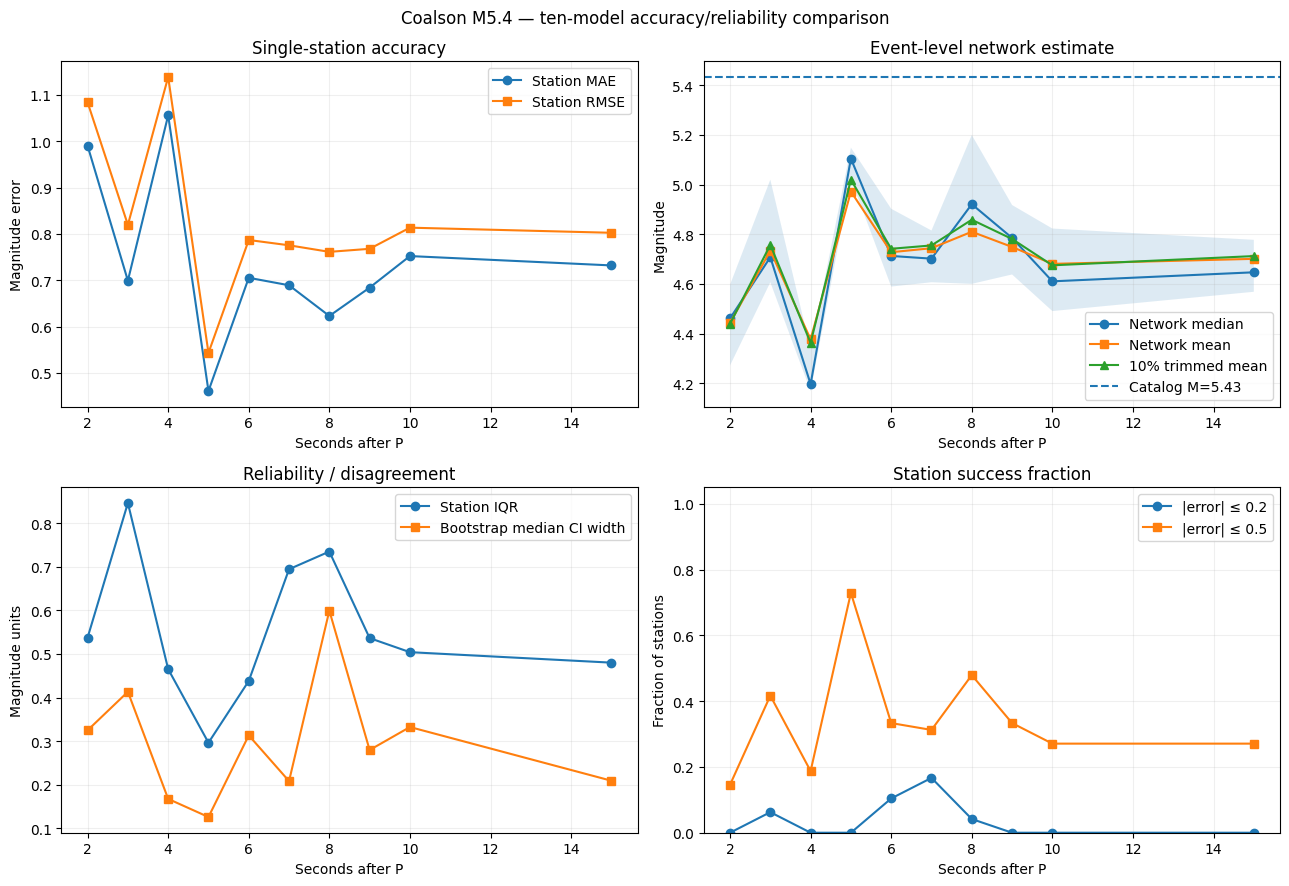

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

ax = axes[0,0]
ax.plot(summary_df.post_p_s, summary_df.station_mae, marker="o", label="Station MAE")
ax.plot(summary_df.post_p_s, summary_df.station_rmse, marker="s", label="Station RMSE")
ax.set(xlabel="Seconds after P", ylabel="Magnitude error",
       title="Single-station accuracy")
ax.grid(alpha=.2); ax.legend()

ax = axes[0,1]
ax.plot(summary_df.post_p_s, summary_df.network_median, marker="o", label="Network median")
ax.plot(summary_df.post_p_s, summary_df.network_mean, marker="s", label="Network mean")
ax.plot(summary_df.post_p_s, summary_df.network_trimmed_mean, marker="^", label="10% trimmed mean")
ax.axhline(TRUE_M, ls="--", label=f"Catalog M={TRUE_M:.2f}")
ax.fill_between(summary_df.post_p_s, summary_df.ci95_lo, summary_df.ci95_hi, alpha=.15)
ax.set(xlabel="Seconds after P", ylabel="Magnitude",
       title="Event-level network estimate")
ax.grid(alpha=.2); ax.legend()

ax = axes[1,0]
ax.plot(summary_df.post_p_s, summary_df.station_iqr, marker="o", label="Station IQR")
ax.plot(summary_df.post_p_s, summary_df.ci95_width, marker="s", label="Bootstrap median CI width")
ax.set(xlabel="Seconds after P", ylabel="Magnitude units",
       title="Reliability / disagreement")
ax.grid(alpha=.2); ax.legend()

ax = axes[1,1]
ax.plot(summary_df.post_p_s, summary_df.frac_within_0p2, marker="o", label="|error| ≤ 0.2")
ax.plot(summary_df.post_p_s, summary_df.frac_within_0p5, marker="s", label="|error| ≤ 0.5")
ax.set(xlabel="Seconds after P", ylabel="Fraction of stations", ylim=(0,1.05),
       title="Station success fraction")
ax.grid(alpha=.2); ax.legend()

fig.suptitle("Coalson M5.4 — ten-model accuracy/reliability comparison")
plt.tight_layout()
plt.show()

## 11. Station × horizon heatmap: where does magnitude information improve?

This is one of the most diagnostic views. Rows are stations and columns are post-P horizons. It reveals whether later windows improve most stations consistently or whether apparent network improvement is driven by a few stations.

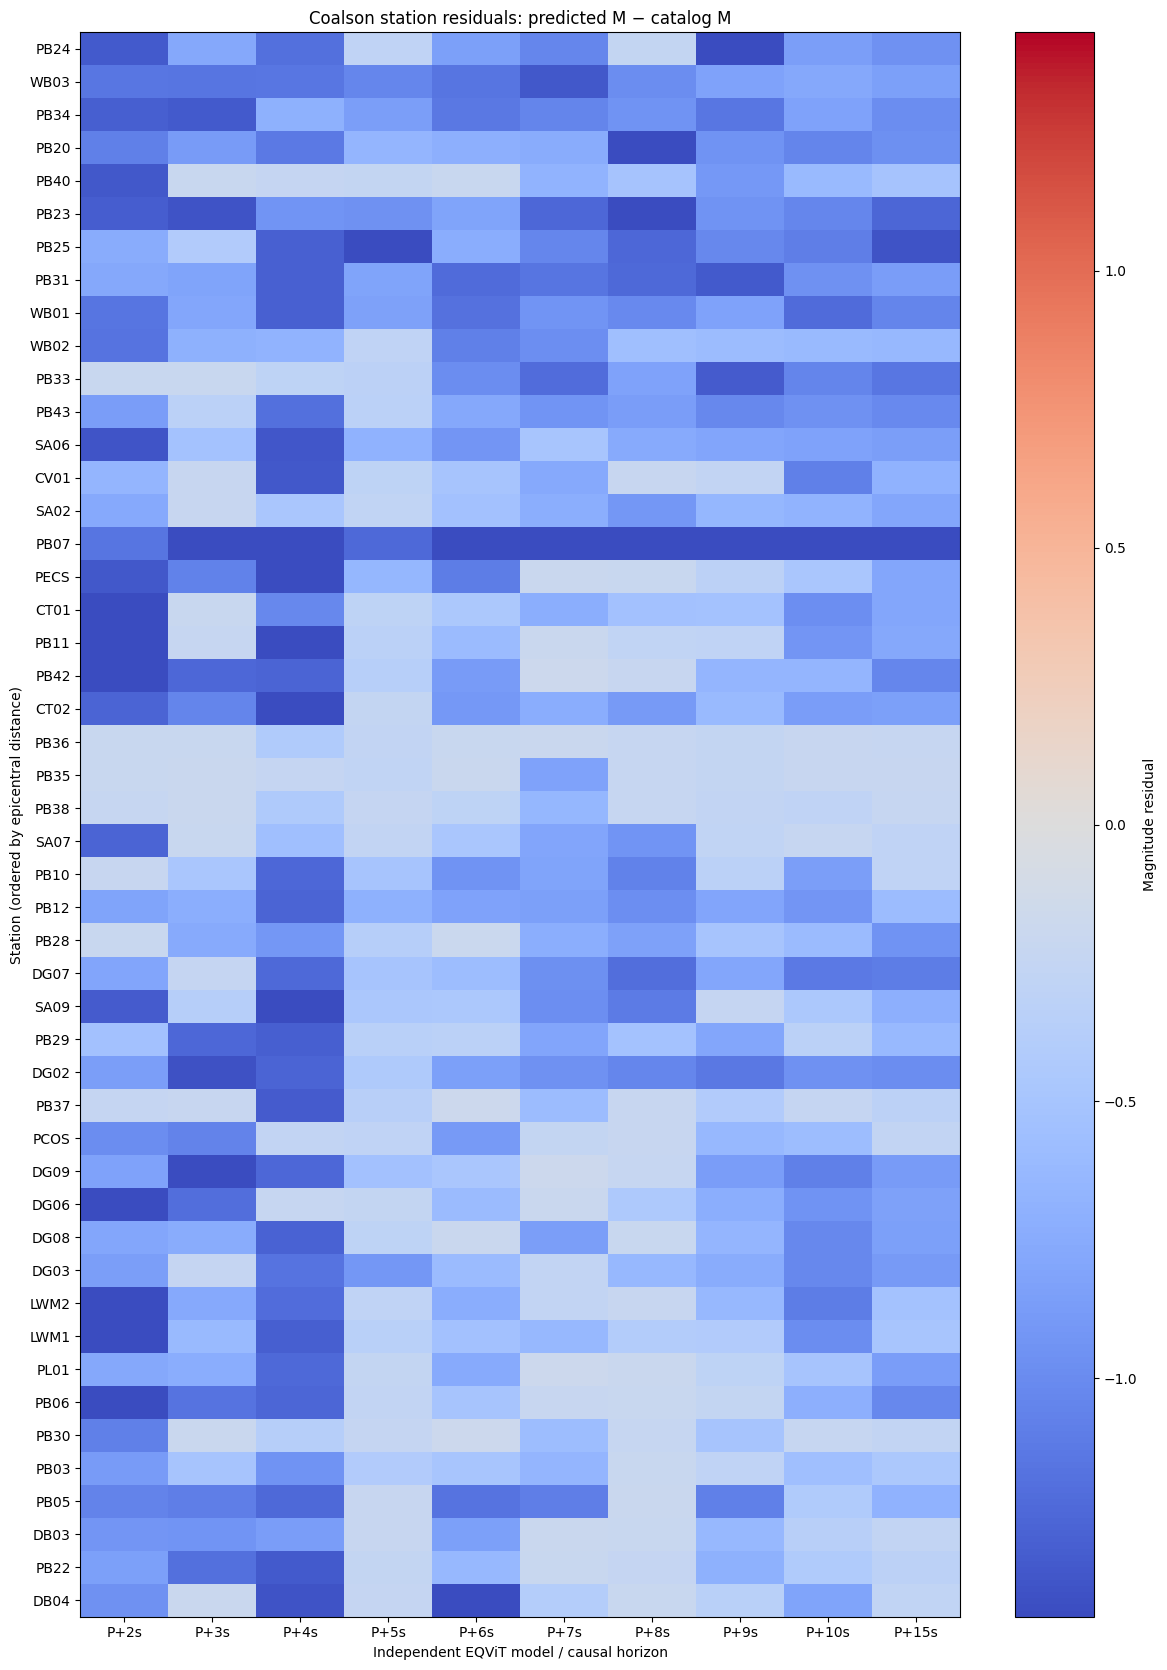

In [12]:
heat = pred_all.pivot_table(
    index="station", columns="post_p_s", values="residual", aggfunc="first"
)
# Order stations by distance for physical interpretability.
dist_order = (pred_all.groupby("station").distance_km_approx.median()
              .sort_values().index)
heat = heat.reindex(dist_order)

fig, ax = plt.subplots(figsize=(12, max(6, .35*len(heat))))
im = ax.imshow(heat.values, aspect="auto", cmap="coolwarm",
               vmin=-max(.8, np.nanquantile(np.abs(heat.values), .95)),
               vmax=max(.8, np.nanquantile(np.abs(heat.values), .95)))
ax.set_xticks(np.arange(len(heat.columns)), [f"P+{x}s" for x in heat.columns])
ax.set_yticks(np.arange(len(heat.index)), heat.index)
ax.set_xlabel("Independent EQViT model / causal horizon")
ax.set_ylabel("Station (ordered by epicentral distance)")
ax.set_title("Coalson station residuals: predicted M − catalog M")
plt.colorbar(im, ax=ax, label="Magnitude residual")
plt.tight_layout()
plt.show()

## 12. Paired improvement relative to P+2 s

Because the same stations appear at all horizons, paired differences are more informative than comparing two unrelated MAEs.

A negative `Δ|error|` means the later model improves that station relative to P+2 s.

,post_p_s,median_delta_abs_error,mean_delta_abs_error,frac_stations_improved,frac_stations_worsened
0,2,0.0000,0.0000,0.0000,0.0000
1,3,-0.2439,-0.2910,0.7083,0.2917
2,4,0.1057,0.0658,0.3958,0.6042
3,5,-0.4948,-0.5293,0.7708,0.2292
4,6,-0.2029,-0.2849,0.7917,0.2083
5,7,-0.2465,-0.3010,0.6250,0.3750
6,8,-0.3703,-0.3673,0.6875,0.3125
7,9,-0.2271,-0.3061,0.6667,0.3333
8,10,-0.2785,-0.2380,0.6042,0.3958
9,15,-0.2653,-0.2582,0.5833,0.4167


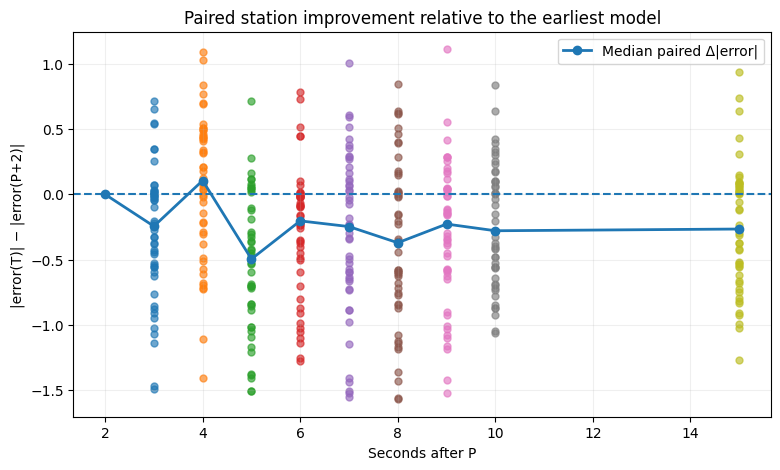

In [13]:
wide_err = pred_all.pivot_table(
    index=["network","station"], columns="post_p_s", values="abs_error", aggfunc="first"
)
paired_rows = []
base = wide_err[2]
for T in POST_P_WINDOWS_S:
    delta = wide_err[T] - base
    paired_rows.append(dict(
        post_p_s=T,
        median_delta_abs_error=float(np.nanmedian(delta)),
        mean_delta_abs_error=float(np.nanmean(delta)),
        frac_stations_improved=float(np.nanmean(delta < 0)) if T != 2 else 0.0,
        frac_stations_worsened=float(np.nanmean(delta > 0)) if T != 2 else 0.0,
    ))
paired_df = pd.DataFrame(paired_rows)
display(paired_df.round(4))

fig, ax = plt.subplots(figsize=(9,5))
for T in POST_P_WINDOWS_S[1:]:
    delta = wide_err[T] - wide_err[2]
    ax.scatter(np.full(delta.notna().sum(), T), delta.dropna(), s=25, alpha=.65)
ax.plot(paired_df.post_p_s, paired_df.median_delta_abs_error,
        marker="o", lw=2, label="Median paired Δ|error|")
ax.axhline(0, ls="--")
ax.set(xlabel="Seconds after P", ylabel="|error(T)| − |error(P+2)|",
       title="Paired station improvement relative to the earliest model")
ax.grid(alpha=.2); ax.legend()
plt.show()

## 13. Full prediction trajectories for every station

Each thin trajectory is one station. The thicker network-median curve shows the robust event estimate. This makes systematic early underestimation/overestimation and late convergence visually obvious.

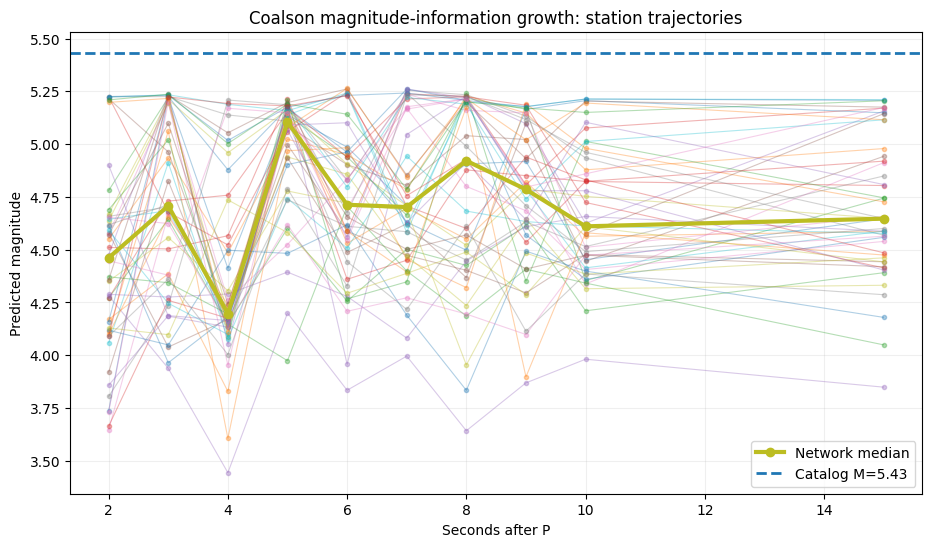

In [14]:
fig, ax = plt.subplots(figsize=(11,6))
for (net, sta), d in pred_all.groupby(["network","station"]):
    d = d.sort_values("post_p_s")
    ax.plot(d.post_p_s, d.predicted_magnitude, marker=".", lw=.8, alpha=.35)
ax.plot(summary_df.post_p_s, summary_df.network_median,
        marker="o", lw=3, label="Network median")
ax.axhline(TRUE_M, ls="--", lw=2, label=f"Catalog M={TRUE_M:.2f}")
ax.set(xlabel="Seconds after P", ylabel="Predicted magnitude",
       title="Coalson magnitude-information growth: station trajectories")
ax.grid(alpha=.2); ax.legend()
plt.show()

## 14. Distance, SNR, and amplitude dependence

A model that works only at nearby/high-SNR stations is less reliable operationally. We inspect residuals against three station-quality proxies at early, intermediate, and late horizons.

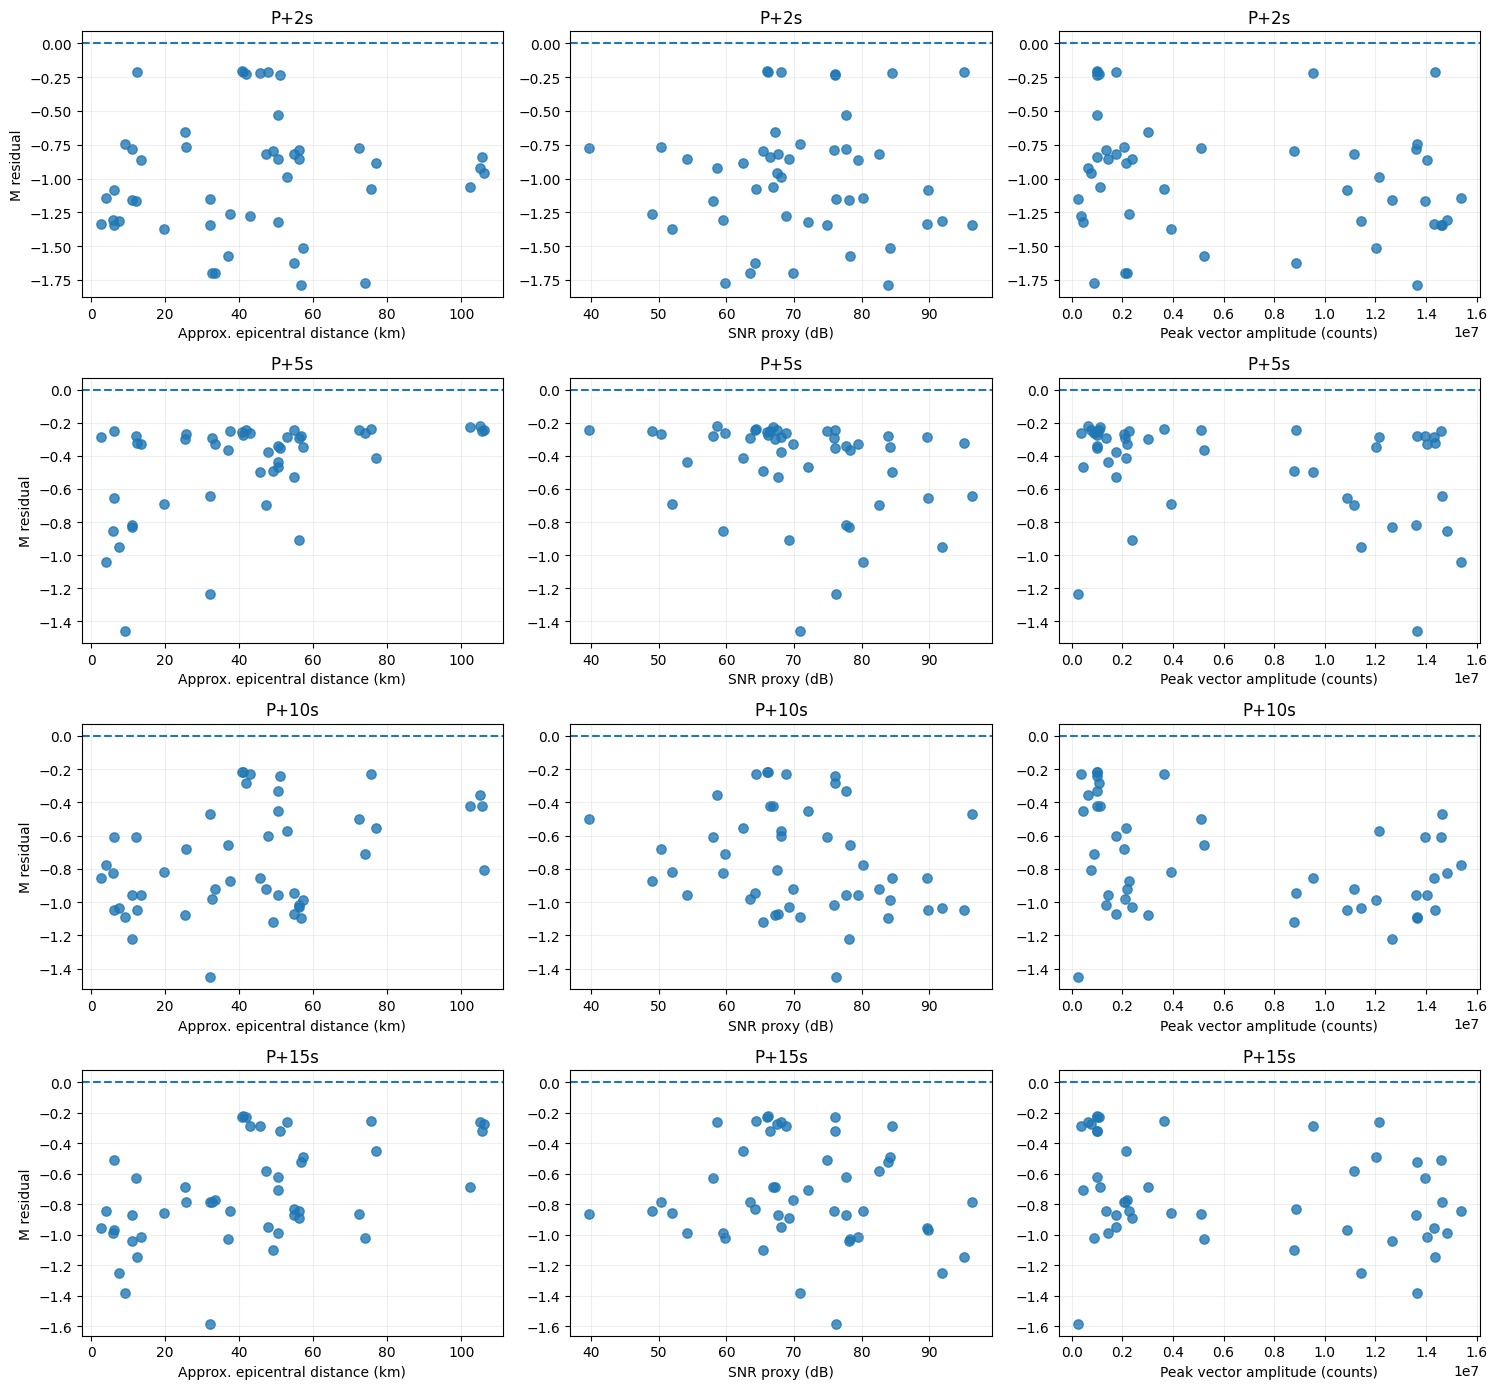

,post_p_s,variable,corr_residual,corr_abs_error
0,2,distance_km_approx,0.065,-0.065
1,2,snr_proxy_db,0.022,-0.022
2,2,peak_vector_counts,-0.206,0.206
3,3,distance_km_approx,-0.050,0.050
4,3,snr_proxy_db,-0.038,0.038
5,3,peak_vector_counts,-0.105,0.105
6,4,distance_km_approx,-0.097,0.097
7,4,snr_proxy_db,-0.092,0.092
8,4,peak_vector_counts,0.154,-0.154
9,5,distance_km_approx,0.462,-0.462


In [15]:
selected_T = [2,5,10,15]
fig, axes = plt.subplots(len(selected_T), 3, figsize=(15, 3.5*len(selected_T)))

for i, T in enumerate(selected_T):
    d = pred_all[pred_all.post_p_s == T]
    for j, (xcol, xlabel) in enumerate([
        ("distance_km_approx","Approx. epicentral distance (km)"),
        ("snr_proxy_db","SNR proxy (dB)"),
        ("peak_vector_counts","Peak vector amplitude (counts)"),
    ]):
        ax = axes[i,j]
        ax.scatter(d[xcol], d.residual, s=45, alpha=.8)
        ax.axhline(0, ls="--")
        ax.set(xlabel=xlabel, ylabel="M residual" if j==0 else "",
               title=f"P+{T}s")
        ax.grid(alpha=.2)
plt.tight_layout()
plt.show()

diag_rows=[]
for T,d in pred_all.groupby("post_p_s"):
    for xcol in ["distance_km_approx","snr_proxy_db","peak_vector_counts"]:
        q=d[[xcol,"residual","abs_error"]].replace([np.inf,-np.inf],np.nan).dropna()
        diag_rows.append(dict(
            post_p_s=T, variable=xcol,
            corr_residual=float(q[xcol].corr(q.residual)) if len(q)>2 else np.nan,
            corr_abs_error=float(q[xcol].corr(q.abs_error)) if len(q)>2 else np.nan,
        ))
diag_df=pd.DataFrame(diag_rows)
display(diag_df.round(3))

## 15. True causal EEW replay: model horizon **and** station arrival time matter

A P+5 s model at a nearby station may become available before a P+2 s model at a distant station. Therefore operational latency must be measured from event origin:

`availability = observed P-arrival elapsed time + model horizon`.

For each horizon, we replay stations in availability order and recompute the running network median.

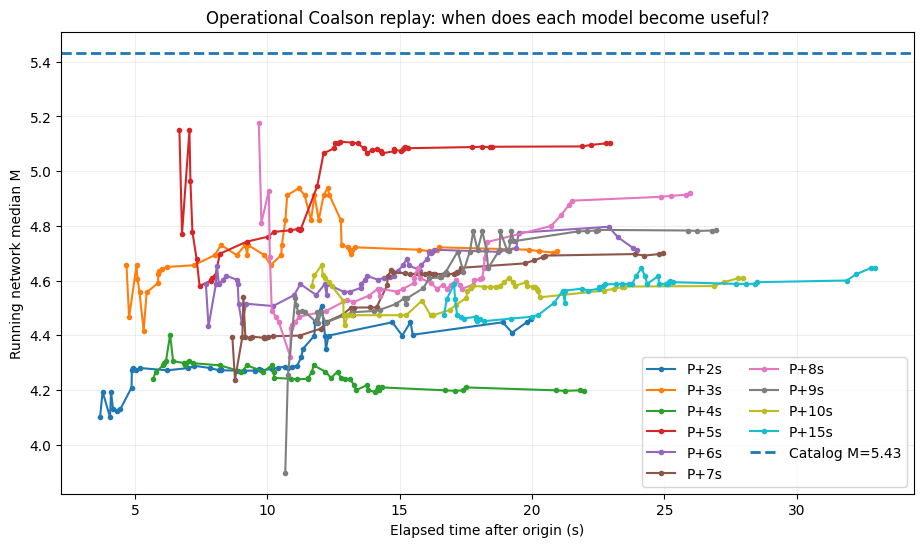

In [16]:
replay_rows=[]
for T,d in pred_all.groupby("post_p_s"):
    eew=d.sort_values("available_at_elapsed_s").reset_index(drop=True)
    for i in range(len(eew)):
        z=eew.iloc[:i+1]
        replay_rows.append(dict(
            post_p_s=T,
            n_stations=i+1,
            elapsed_s=float(z.available_at_elapsed_s.iloc[-1]),
            running_median=float(z.predicted_magnitude.median()),
            running_mean=float(z.predicted_magnitude.mean()),
            abs_error_median=float(abs(z.predicted_magnitude.median()-TRUE_M)),
        ))
replay=pd.DataFrame(replay_rows)
replay.to_csv(OUTPUT_DIR/"coalson_causal_replay_all_horizons.csv",index=False)

fig, ax=plt.subplots(figsize=(11,6))
for T,d in replay.groupby("post_p_s"):
    ax.plot(d.elapsed_s,d.running_median,marker=".",label=f"P+{T}s")
ax.axhline(TRUE_M,ls="--",lw=2,label=f"Catalog M={TRUE_M:.2f}")
ax.set(xlabel="Elapsed time after origin (s)",ylabel="Running network median M",
       title="Operational Coalson replay: when does each model become useful?")
ax.grid(alpha=.2); ax.legend(ncol=2)
plt.show()

## 16. Time-to-accuracy analysis

For each model we measure the earliest origin-relative time at which the running network median enters a specified error band **and remains there for all subsequent station updates**. This is stricter than reporting the first lucky crossing.

,post_p_s,stable_time_err_le_0.2,stations_at_0.2,stable_time_err_le_0.3,stations_at_0.3,stable_time_err_le_0.5,stations_at_0.5
0,2,NaN,NaN,NaN,NaN,NaN,NaN
1,3,NaN,NaN,NaN,NaN,NaN,NaN
2,4,NaN,NaN,NaN,NaN,NaN,NaN
3,5,NaN,NaN,NaN,NaN,11.884689,20.0
4,6,NaN,NaN,NaN,NaN,NaN,NaN
5,7,NaN,NaN,NaN,NaN,NaN,NaN
6,8,NaN,NaN,NaN,NaN,NaN,NaN
7,9,NaN,NaN,NaN,NaN,NaN,NaN
8,10,NaN,NaN,NaN,NaN,NaN,NaN
9,15,NaN,NaN,NaN,NaN,NaN,NaN


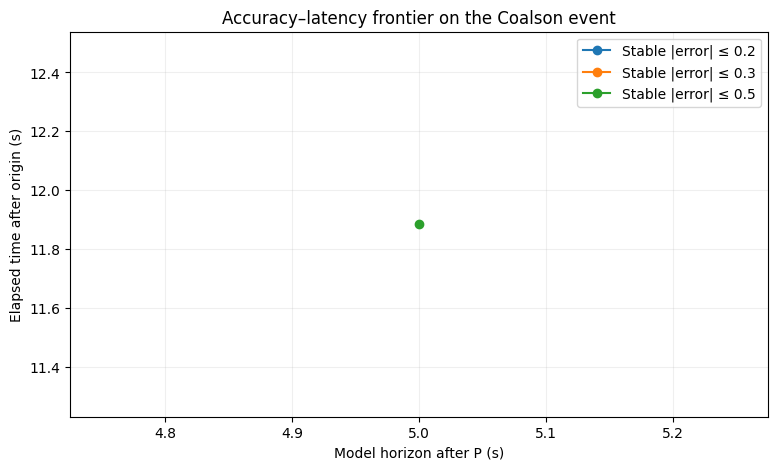

In [17]:
def stable_time_to_tolerance(d, tol):
    d=d.sort_values("elapsed_s").reset_index(drop=True)
    ok=d.abs_error_median.to_numpy() <= tol
    for i in range(len(ok)):
        if ok[i:].all():
            return float(d.elapsed_s.iloc[i]), int(d.n_stations.iloc[i])
    return np.nan, np.nan

tta=[]
for T,d in replay.groupby("post_p_s"):
    row={"post_p_s":T}
    for tol in [.2,.3,.5]:
        tt,nn=stable_time_to_tolerance(d,tol)
        row[f"stable_time_err_le_{tol:.1f}"]=tt
        row[f"stations_at_{tol:.1f}"]=nn
    tta.append(row)
tta_df=pd.DataFrame(tta).sort_values("post_p_s")
display(tta_df)

fig,ax=plt.subplots(figsize=(9,5))
for tol in [.2,.3,.5]:
    ax.plot(tta_df.post_p_s,tta_df[f"stable_time_err_le_{tol:.1f}"],
            marker="o",label=f"Stable |error| ≤ {tol:.1f}")
ax.set(xlabel="Model horizon after P (s)",ylabel="Elapsed time after origin (s)",
       title="Accuracy–latency frontier on the Coalson event")
ax.grid(alpha=.2); ax.legend()
plt.show()

## 17. Robustness stress test on the **real Coalson waveforms**

The training notebook tests robustness on held-out TXED records. Here we repeat analogous perturbations on the Coalson event itself.

Perturbations are applied only to samples already visible at horizon T; the future remains zero. This answers a practical question: *which horizon is least fragile when real-time picks or telemetry are imperfect?*

In [18]:
def perturb_visible(w, T, kind="clean", value=None, seed=0):
    z=w.copy()
    visible_n=int(round((PRE_P_S+T)*FS))
    v=z[:visible_n]
    rr=np.random.default_rng(seed)

    if kind=="noise":
        rms=np.sqrt(np.mean(v*v,axis=0,keepdims=True)+1e-12)
        v += rr.normal(0,1,v.shape).astype(np.float32)*rms*float(value)
    elif kind=="gain":
        v *= float(value)
    elif kind=="drop_component":
        v[:,1]=0
    elif kind=="clip":
        q=np.quantile(np.abs(v),float(value))
        if q>0: np.clip(v,-q,q,out=v)
    elif kind=="gap":
        L=min(int(float(value)*FS),max(1,visible_n//3))
        st=max(PRE_N,min(visible_n-L,PRE_N+int(.5*FS)))
        v[st:st+L]=0
    z[:visible_n]=v
    z[visible_n:]=0
    return z

STRESS_CASES=[
    ("clean",None,"Clean"),
    ("noise",.20,"Added noise (20% RMS)"),
    ("gain",1.25,"Gain ×1.25"),
    ("drop_component",None,"Missing horizontal"),
    ("clip",.97,"97% clipping threshold"),
    ("gap",.30,"0.30-s gap"),
]

stress_rows=[]
for T in POST_P_WINDOWS_S:
    model,_=load_horizon_model(T)
    for kind,value,label in STRESS_CASES:
        vals=[]
        for k,(key,full_w) in enumerate(full_windows.items()):
            w=causalize(full_w,T)
            w=perturb_visible(w,T,kind,value,seed=SEED+1000*T+k)
            vals.append(infer_model(model,w))
        vals=np.asarray(vals)
        e=vals-TRUE_M
        stress_rows.append(dict(
            post_p_s=T, scenario=label,
            station_mae=float(np.mean(np.abs(e))),
            network_median=float(np.median(vals)),
            network_median_abs_error=float(abs(np.median(vals)-TRUE_M)),
            station_std=float(np.std(vals)),
        ))
    del model
    if DEVICE=="cuda": torch.cuda.empty_cache()

stress_df=pd.DataFrame(stress_rows)
clean_mae=stress_df[stress_df.scenario=="Clean"].set_index("post_p_s").station_mae
stress_df["mae_degradation"]=stress_df.apply(
    lambda r:r.station_mae-clean_mae.loc[r.post_p_s],axis=1)
stress_df.to_csv(OUTPUT_DIR/"coalson_real_event_robustness.csv",index=False)
display(stress_df.pivot(index="post_p_s",columns="scenario",values="station_mae").round(3))

scenario,0.30-s gap,97% clipping threshold,Added noise (20% RMS),Clean,Gain ×1.25,Missing horizontal
post_p_s,,,,,,
2,0.920,0.981,0.848,0.990,0.977,0.869
3,0.742,0.694,0.869,0.699,0.686,0.722
4,1.104,1.061,1.061,1.056,1.047,0.964
5,0.483,0.452,0.556,0.461,0.452,0.463
6,0.578,0.685,0.762,0.705,0.697,0.520
7,0.666,0.667,0.762,0.689,0.677,0.570
8,0.633,0.609,0.638,0.623,0.617,0.557
9,0.678,0.663,0.792,0.684,0.675,0.553
10,0.740,0.726,0.839,0.752,0.748,0.730


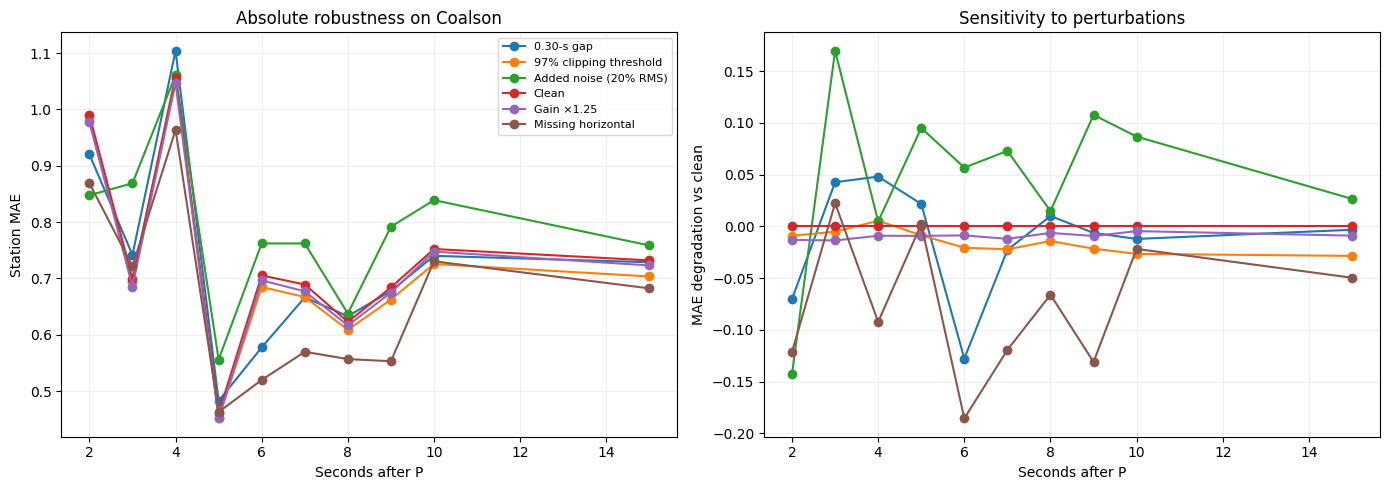

In [19]:
fig,axes=plt.subplots(1,2,figsize=(14,5))
for label,d in stress_df.groupby("scenario"):
    axes[0].plot(d.post_p_s,d.station_mae,marker="o",label=label)
    axes[1].plot(d.post_p_s,d.mae_degradation,marker="o",label=label)
axes[0].set(xlabel="Seconds after P",ylabel="Station MAE",
            title="Absolute robustness on Coalson")
axes[1].set(xlabel="Seconds after P",ylabel="MAE degradation vs clean",
            title="Sensitivity to perturbations")
for ax in axes: ax.grid(alpha=.2)
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

## 18. P-pick timing sensitivity

Pick error deserves a separate test because changing P changes **both alignment and the actual waveform segment exposed to the model**. We rebuild the full P-centered tensor from the ObsPy stream at shifted pick times, then apply the same horizon mask.

/tmp/ipykernel_948607/1656795470.py:10: PerformanceWarning: indexing past lexsort depth may impact performance.
  r=pick_lookup.loc[key]


,post_p_s,pick_shift_s,n,station_mae,network_median,network_median_abs_error
0,2,-0.5,48,0.971,4.467,0.966
1,2,0.5,48,0.947,4.527,0.906
2,2,1.0,48,1.361,4.004,1.429
3,3,-0.5,48,0.708,4.705,0.728
4,3,0.5,48,0.781,4.616,0.817
5,3,1.0,48,1.154,4.234,1.199
6,4,-0.5,48,0.904,4.536,0.897
7,4,0.5,48,1.121,4.180,1.253
8,4,1.0,48,1.364,4.091,1.342
9,5,-0.5,48,0.421,5.159,0.274


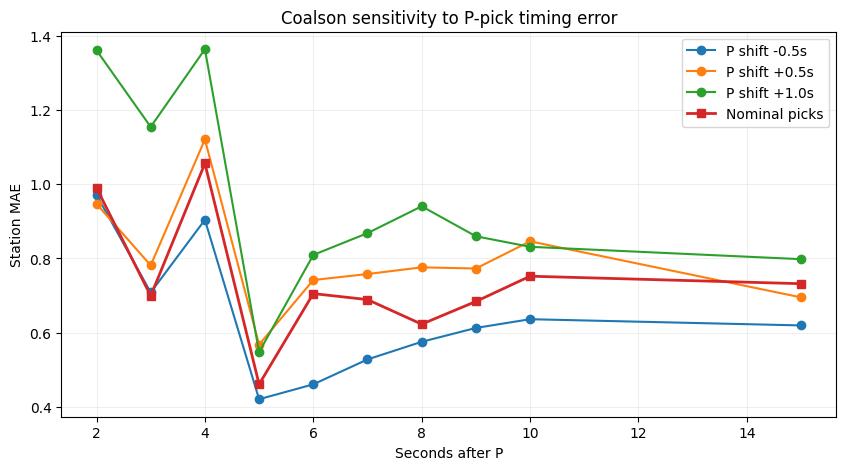

In [20]:
PICK_SHIFTS_S=[-.5,.5,1.0]
pickstress=[]

for T in POST_P_WINDOWS_S:
    model,_=load_horizon_model(T)
    for shift in PICK_SHIFTS_S:
        vals=[]
        for key in full_windows:
            net,sta=key
            r=pick_lookup.loc[key]
            if isinstance(r,pd.DataFrame): r=r.iloc[0]
            try:
                shifted_full,_,_=station_to_full_window(streams[key],r.p_time+shift)
                w=causalize(shifted_full,T)
                vals.append(infer_model(model,w))
            except Exception:
                pass
        vals=np.asarray(vals,float)
        e=vals-TRUE_M
        pickstress.append(dict(
            post_p_s=T,pick_shift_s=shift,n=len(vals),
            station_mae=float(np.mean(np.abs(e))),
            network_median=float(np.median(vals)),
            network_median_abs_error=float(abs(np.median(vals)-TRUE_M)),
        ))
    del model
    if DEVICE=="cuda": torch.cuda.empty_cache()

pickstress_df=pd.DataFrame(pickstress)
display(pickstress_df.round(3))

fig,ax=plt.subplots(figsize=(10,5))
for shift,d in pickstress_df.groupby("pick_shift_s"):
    ax.plot(d.post_p_s,d.station_mae,marker="o",label=f"P shift {shift:+.1f}s")
ax.plot(summary_df.post_p_s,summary_df.station_mae,marker="s",lw=2,label="Nominal picks")
ax.set(xlabel="Seconds after P",ylabel="Station MAE",
       title="Coalson sensitivity to P-pick timing error")
ax.grid(alpha=.2); ax.legend()
plt.show()

## 19. Optional old 30-s model baseline

Notebook 06 used a P−1/P+29 s model. If that checkpoint is present, this section evaluates it on the **same station tensors** and appends it as an explicit long-latency baseline.

This comparison should be interpreted carefully: the old model and the new ten-model suite may differ in training protocol, not only in visible duration. The old result is therefore a useful operational reference, not a controlled ablation of window length alone.

In [21]:
old_summary=None
if OLD_BEST is None or not OLD_BEST.exists():
    print("Old 30-s checkpoint not found — skipping optional baseline.")
else:
    ck=torch.load(OLD_BEST,map_location=DEVICE)
    state=ck["state_dict"] if isinstance(ck,dict) and "state_dict" in ck else ck
    old_model=EQViTMagnitude().to(DEVICE)
    old_model.load_state_dict(state); old_model.eval()

    vals=[]
    for key,full_w in full_windows.items():
        # Old notebook 06: full P-1/P+29 tensor, mean removed across the full tensor.
        w=full_w.copy()
        w=w-w.mean(axis=0,keepdims=True)
        vals.append(infer_model(old_model,w))
    vals=np.asarray(vals)
    e=vals-TRUE_M
    old_summary=dict(
        horizon_label="Old P+29s",
        n_stations=len(vals),
        station_mae=float(np.mean(np.abs(e))),
        station_rmse=float(np.sqrt(np.mean(e*e))),
        station_bias=float(np.mean(e)),
        network_median=float(np.median(vals)),
        network_median_abs_error=float(abs(np.median(vals)-TRUE_M)),
        station_std=float(np.std(vals)),
    )
    print(json.dumps(old_summary,indent=2))
    del old_model

{
  "horizon_label": "Old P+29s",
  "n_stations": 48,
  "station_mae": 0.9052751782787988,
  "station_rmse": 1.0964921993844539,
  "station_bias": -0.9052751782787988,
  "network_median": 4.614617347717285,
  "network_median_abs_error": 0.8183607382827152,
  "station_std": 0.6186856996110757
}


## 20. Model-selection scorecard

There is no universally “best” horizon. The preferred operating point depends on whether the objective is:

- **Earliest usable estimate**,
- **balanced latency + accuracy + stability**, or
- **maximum accuracy**.

The score below is intentionally transparent rather than hidden in a black-box ranking. Metrics are min-max normalized across the ten Coalson models:

- event median absolute error,
- station MAE,
- station disagreement (IQR),
- bootstrap uncertainty width,
- mean robustness degradation,
- horizon latency.

The default balanced score gives accuracy the largest weight but still penalizes latency and fragility. Change `WEIGHTS` to match the operational priorities of Texas EEW.

In [22]:
robust_agg=(stress_df[stress_df.scenario!="Clean"]
            .groupby("post_p_s").mae_degradation.mean()
            .rename("mean_stress_degradation"))
score=summary_df.merge(robust_agg,on="post_p_s",how="left")

METRICS=[
    "network_median_abs_error","station_mae","station_iqr",
    "ci95_width","mean_stress_degradation","post_p_s"
]
WEIGHTS={
    "network_median_abs_error":0.30,
    "station_mae":0.20,
    "station_iqr":0.10,
    "ci95_width":0.10,
    "mean_stress_degradation":0.10,
    "post_p_s":0.20,
}

for m in METRICS:
    x=score[m].astype(float)
    den=x.max()-x.min()
    score[m+"_norm"]=0.0 if den==0 else (x-x.min())/den

score["balanced_score"]=sum(WEIGHTS[m]*score[m+"_norm"] for m in METRICS)
score["rank_balanced"]=score.balanced_score.rank(method="min").astype(int)
score=score.sort_values("rank_balanced")
score.to_csv(OUTPUT_DIR/"coalson_model_selection_scorecard.csv",index=False)

display(score[[
    "rank_balanced","post_p_s","network_median_abs_error","station_mae",
    "station_iqr","ci95_width","mean_stress_degradation","balanced_score"
]].round(4))

best_balanced=int(score.iloc[0].post_p_s)
best_event=int(summary_df.loc[summary_df.network_median_abs_error.idxmin(),"post_p_s"])
best_station=int(summary_df.loc[summary_df.station_mae.idxmin(),"post_p_s"])
print("Best balanced horizon: P+",best_balanced,"s")
print("Best event-median accuracy: P+",best_event,"s")
print("Best station MAE: P+",best_station,"s")

,rank_balanced,post_p_s,network_median_abs_error,station_mae,station_iqr,ci95_width,mean_stress_degradation,balanced_score
3,1,5,0.3283,0.4609,0.2964,0.1260,0.0202,0.1260
4,2,6,0.7204,0.7053,0.4379,0.3132,-0.0572,0.3509
7,3,9,0.6478,0.6841,0.5363,0.2796,-0.0121,0.4160
5,4,7,0.7312,0.6892,0.6943,0.2083,-0.0207,0.4207
6,5,8,0.5120,0.6229,0.7347,0.5992,-0.0124,0.4387
0,6,2,0.9718,0.9902,0.5374,0.3248,-0.0713,0.4764
1,7,3,0.7254,0.6992,0.8460,0.4132,0.0432,0.4873
8,8,10,0.8225,0.7522,0.5040,0.3323,0.0043,0.5317
9,9,15,0.7862,0.7320,0.4800,0.2092,-0.0128,0.5445
2,10,4,1.2362,1.0560,0.4651,0.1675,-0.0086,0.6250


Best balanced horizon: P+ 5 s
Best event-median accuracy: P+ 5 s
Best station MAE: P+ 5 s


## 21. Pareto frontier: accuracy versus model latency

A horizon is Pareto-dominated if another model is both earlier and at least as accurate in the chosen metric. The non-dominated models are the most defensible candidates for an operational update schedule.

,post_p_s,network_median_abs_error,station_mae,pareto_event_error
0,2,0.971761,0.990210,True
1,3,0.725409,0.699165,True
2,4,1.236236,1.056000,False
3,5,0.328350,0.460925,True
4,6,0.720380,0.705332,False
5,7,0.731215,0.689187,False
6,8,0.512002,0.622946,False
7,9,0.647764,0.684094,False
8,10,0.822547,0.752221,False
9,15,0.786156,0.732033,False


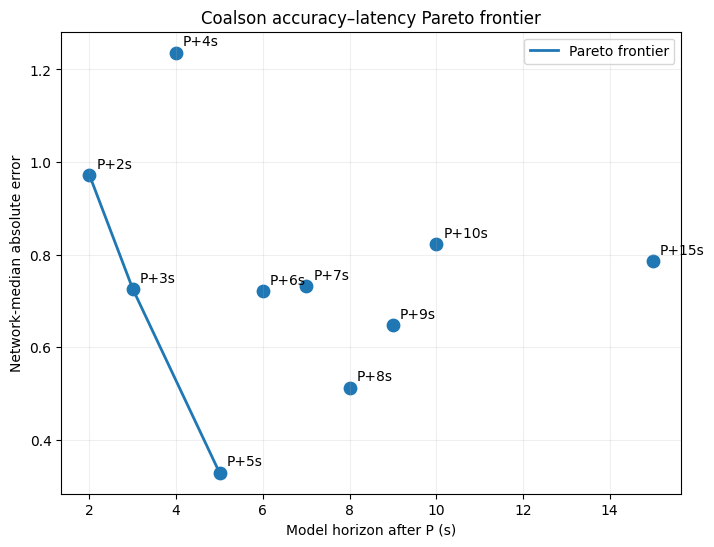

In [23]:
pareto=summary_df[["post_p_s","network_median_abs_error","station_mae"]].copy()

def nondominated(df,x="post_p_s",y="network_median_abs_error"):
    keep=[]
    for i,r in df.iterrows():
        dominated=((df[x] <= r[x]) & (df[y] <= r[y]) &
                   ((df[x] < r[x]) | (df[y] < r[y]))).any()
        keep.append(not dominated)
    return np.asarray(keep)

pareto["pareto_event_error"]=nondominated(pareto)
display(pareto)

fig,ax=plt.subplots(figsize=(8,6))
ax.scatter(pareto.post_p_s,pareto.network_median_abs_error,s=80)
for r in pareto.itertuples():
    ax.annotate(f"P+{r.post_p_s}s",(r.post_p_s,r.network_median_abs_error),
                xytext=(5,5),textcoords="offset points")
p=pareto[pareto.pareto_event_error].sort_values("post_p_s")
ax.plot(p.post_p_s,p.network_median_abs_error,lw=2,label="Pareto frontier")
ax.set(xlabel="Model horizon after P (s)",ylabel="Network-median absolute error",
       title="Coalson accuracy–latency Pareto frontier")
ax.grid(alpha=.2); ax.legend()
plt.show()

## 22. Automatic interpretation table

This cell turns the numerical results into a compact decision table. It intentionally reports several definitions of “best” rather than forcing one conclusion.

In [24]:
decision = pd.DataFrame([
    ["Earliest model", 2,
     "Minimum model latency; inspect whether its error/reliability is already acceptable."],
    ["Lowest event-median error",
     int(summary_df.loc[summary_df.network_median_abs_error.idxmin(),"post_p_s"]),
     "Best final fused magnitude for this event."],
    ["Lowest station MAE",
     int(summary_df.loc[summary_df.station_mae.idxmin(),"post_p_s"]),
     "Best average single-station accuracy."],
    ["Tightest station agreement",
     int(summary_df.loc[summary_df.station_iqr.idxmin(),"post_p_s"]),
     "Smallest interquartile spread across stations."],
    ["Tightest bootstrap CI",
     int(summary_df.loc[summary_df.ci95_width.idxmin(),"post_p_s"]),
     "Most stable network median under station resampling."],
    ["Balanced score",
     best_balanced,
     "Best default compromise under the explicit weights in Section 20."],
], columns=["criterion","recommended_post_p_s","interpretation"])
display(decision)

,criterion,recommended_post_p_s,interpretation
0,Earliest model,2,Minimum model latency; inspect whether its err...
1,Lowest event-median error,5,Best final fused magnitude for this event.
2,Lowest station MAE,5,Best average single-station accuracy.
3,Tightest station agreement,5,Smallest interquartile spread across stations.
4,Tightest bootstrap CI,5,Most stable network median under station resam...
5,Balanced score,5,Best default compromise under the explicit wei...


## 23. Save a compact machine-readable report

The JSON report makes this notebook easy to integrate into the larger Texas EEW workflow.

In [25]:
bestrow=summary_df.set_index("post_p_s").loc[best_balanced]
report={
    "event":{
        "catalog_magnitude":TRUE_M,
        "origin_time":str(ORIGIN_TIME),
        "latitude":EV_LAT,"longitude":EV_LON,"depth_km":EV_DEPTH_KM,
    },
    "experiment":{
        "horizons_s":POST_P_WINDOWS_S,
        "usable_stations":int(pred_all.station.nunique()),
        "pre_p_s":PRE_P_S,
        "sample_rate_hz":FS,
        "model_tensor_samples":MODEL_N,
        "strict_future_masking":True,
    },
    "balanced_selection":{
        "post_p_s":best_balanced,
        "network_median":float(bestrow.network_median),
        "network_median_abs_error":float(bestrow.network_median_abs_error),
        "station_mae":float(bestrow.station_mae),
        "station_iqr":float(bestrow.station_iqr),
        "bootstrap_ci95":[float(bestrow.ci95_lo),float(bestrow.ci95_hi)],
        "weights":WEIGHTS,
    },
    "best_event_accuracy_post_p_s":best_event,
    "best_station_mae_post_p_s":best_station,
    "old_30s_baseline":old_summary,
}
with open(OUTPUT_DIR/"coalson_multiwindow_final_report.json","w") as f:
    json.dump(report,f,indent=2)
print(json.dumps(report,indent=2))

{
  "event": {
    "catalog_magnitude": 5.432978086,
    "origin_time": "2022-11-16T21:32:44.481830Z",
    "latitude": 31.6367452,
    "longitude": -103.9987871,
    "depth_km": 6.902807617000001
  },
  "experiment": {
    "horizons_s": [
      2,
      3,
      4,
      5,
      6,
      7,
      8,
      9,
      10,
      15
    ],
    "usable_stations": 48,
    "pre_p_s": 1.0,
    "sample_rate_hz": 100.0,
    "model_tensor_samples": 3000,
    "strict_future_masking": true
  },
  "balanced_selection": {
    "post_p_s": 5,
    "network_median": 5.104628086090088,
    "network_median_abs_error": 0.3283499999099124,
    "station_mae": 0.4609250250710198,
    "station_iqr": 0.2963773012161255,
    "bootstrap_ci95": [
      5.0228271484375,
      5.148802280426025
    ],
    "weights": {
      "network_median_abs_error": 0.3,
      "station_mae": 0.2,
      "station_iqr": 0.1,
      "ci95_width": 0.1,
      "mean_stress_degradation": 0.1,
      "post_p_s": 0.2
    }
  },
  "best_event_ac

# Interpretation guide: how to tackle EEW magnitude estimation well

The experiment is designed to support an **update strategy**, not merely select one static model.

### 1. Do not wait for one long window if a useful early estimate exists
The P+2/P+3/P+4 models can provide the first magnitude evidence substantially earlier than the old P+29 model. Their value is operational even if their final MAE is not the minimum.

### 2. Do not judge the models from station MAE alone
For an EEW application, the network-fused magnitude, uncertainty, station disagreement, and origin-relative availability are at least as important as average single-station error.

### 3. Prefer a staged magnitude update
A practical system can emit an early estimate from the earliest acceptable model, then replace it with P+5/P+8/P+10/P+15 estimates as more waveform becomes causally available. This directly uses the magnitude-information growth curve learned by the ten independent models.

### 4. Treat large-event underestimation as a first-class diagnostic
Coalson is M5.4, so it is especially useful for testing whether short windows systematically underpredict larger events. Inspect the station trajectories and residual heatmap rather than only the final network median.

### 5. Fuse stations robustly
The median is a strong default baseline. The bootstrap CI and station IQR quantify whether the network agrees. A production system can go further with uncertainty-aware or quality-weighted fusion, but such weighting should be validated rather than assumed.

### 6. Reliability requires perturbation tests
A horizon that is accurate only for perfect picks and complete three-component data may be less useful than a slightly less accurate but more stable horizon. The Coalson stress tests therefore belong in the model-selection decision.

### 7. Separate three kinds of latency
- **Model horizon latency**: P+T.
- **Station trigger latency**: travel time from origin to P at that station.
- **Network convergence latency**: time until enough station estimates produce a stable fused magnitude.

The causal replay explicitly combines the first two and shows the third.

### 8. Recommended next scientific step
Repeat this notebook on a **real-event suite spanning magnitude, distance, region, station type, and SNR**, rather than optimizing the operational choice around one M5.4 event. Coalson should be treated as a demanding case study, not the complete validation set.

The strongest deployment decision will combine:
1. TXED held-out test accuracy,
2. TXED robustness benchmarks,
3. Coalson real-event behavior,
4. a broader TexNet real-event replay suite,
5. operational alert latency and stability.